In [108]:
import math
import numpy
import graphviz
import matplotlib

%matplotlib inline
numpy.set_printoptions(suppress=True)

In [109]:
def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root, format="svg", rankdir="LR"):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    # LR: left to right
    # TB: top to bottom

    assert rankdir in ["LR", "TB"]
    nodes, edges = trace(root)
    dot = graphviz.Digraph(format=format, graph_attr={"rankdir": rankdir})  # , node_attr={'rankdir': 'TB'})

    for n in nodes:
        uid = str(id(n))

        # for any value in the graph, create a rectangular ('record') node for the value.
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape="record")

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to the value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [110]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0

        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), "+")

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), "*")


a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
print(a + b)
print(a * b)

d = a * b
d.label = "d"

e = d + c
e.label = "e"
print(e)
print(e._prev)
print(e._op)

f = Value(-2.0, label="f")

L = e * f
L.label = "L"

Value(data=-1.0)
Value(data=-6.0)
Value(data=4.0)
{Value(data=-6.0), Value(data=10.0)}
+


In [111]:
L.grad = 1.0
f.grad = 4.0
e.grad = -2.0
d.grad = -2.0
c.grad = -2.0
b.grad = -4.0
a.grad = 6.0

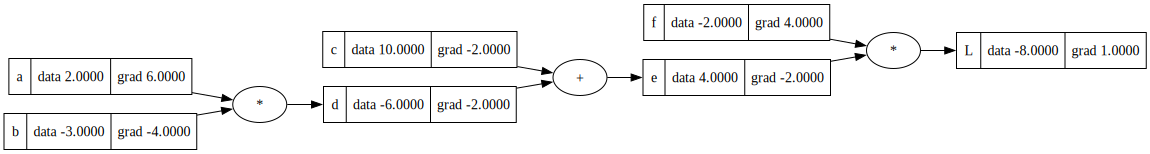

In [112]:
draw_dot(L)

### Derivative of $f$ with respect to $L$:

$L = e * f$

$\frac{dL}{df} = ?$

$\Large{\frac{f(x-h) - f(x)}{h}}$

$f(x-h) = e * (f + h)$

$f(x) = e * f$

$\Large{\frac{e * (f + h) - e * f}{h} = \frac{e * f + h * e - e * f}{h} = \frac{\cancel{e * f} + h * e - \cancel{e * f}}{h} = \frac{h * e}{h} = \frac{\cancel{h} * f}{\cancel{h}} = e = 4.0}$


### Derivative of $e$ with respect to $L$:

$L = e * f$

$\frac{dL}{de} = ?$

$\Large{\frac{f(x-h) - f(x)}{h}}$

$f(x-h) = (e + h) * f$

$f(x) = e * f$

$\Large{\frac{(e + h) * f - e * f}{h} = \frac{e * f + h * f - e * f}{h} = \frac{\cancel{e * f} + h * f - \cancel{e * f}}{h} = \frac{h * f}{h} = \frac{\cancel{h} * f}{\cancel{h}} = f = -2.0}$

### Derivative of $d$ with respect to $L$:

$L = e * f = (c + d) * f$

$\frac{dL}{dd} = ?$

---

$\frac{de}{dd} = ?$

$e = c + d$

$\Large{\frac{f(x-h) - f(x)}{h}}$

$f(x-h) = c + (d + h)$

$f(x) = c + d$

$\Large{\frac{c + (d + h) - (c + d)}{h} = \frac{c + d + h - c - d}{h} = \frac{\cancel{c} + \cancel{d} + h - \cancel{c} - \cancel{d}}{h} = \frac{h}{h} = 1.0}$

---

**Chain rule:**

$\frac{dz}{dx} = \frac{dz}{dy} * \frac{dy}{dx}$

$\frac{dL}{dd} = \frac{dL}{de} * \frac{de}{dd}$

$\frac{de}{dd} = 1.0$

$\frac{dL}{de} = f$

$\frac{dL}{dd} = f * 1.0 = f = -2.0$

### Derivative of $c$ with respect to $L$:

$L = e * f = (c + d) * f$

$\frac{dL}{dc} = ?$

---

$\frac{de}{dc} = ?$

$e = c + d$

$\Large{\frac{f(x-h) - f(x)}{h}}$

$f(x-h) = (c + h) + d$

$f(x) = c + d$

$\Large{\frac{(c + h) + d - (c + d)}{h} = \frac{c + h + d - c - d}{h} = \frac{\cancel{c} + h + \cancel{d} - \cancel{c} - \cancel{d}}{h} = \frac{h}{h} = 1.0}$

---


**Chain rule:**

$\frac{dz}{dx} = \frac{dz}{dy} * \frac{dy}{dx}$

$\frac{dL}{dc} = \frac{dL}{de} * \frac{de}{dc}$

$\frac{de}{dc} = 1.0$

$\frac{dL}{de} = f$

$\frac{dL}{dc} = f * 1.0 = f = -2.0$

### Derivative of $b$ with respect to $L$:

$L = e * f = (c + d) * f = (c + (a * b)) * f$

$e = c + d = c + (a * b)$

$d = a * b$

$\frac{dL}{db} = ?$

---

**Rules:**

$\Large{\frac{f(x-h) - f(x)}{h}}$

$\frac{dz}{dx} = \frac{dz}{dy} * \frac{dy}{dx}$

---

**Full:**

$\frac{dL}{db} = \frac{dL}{de} * \frac{de}{dd} * \frac{dd}{db}$

$\frac{dL}{de} = f = -2.0$

$\frac{de}{dd} = 1.0$

$\frac{dd}{db} = ?$

**Short:**

$\frac{dL}{db} = \frac{dL}{dd} * \frac{dd}{db}$

$\frac{dL}{dd} = f = -2.0$

$\frac{dd}{db} = ?$

---

**$\frac{dd}{db} = ?$**

$d = a * b$

$f(x-h) = a * (b + h)$

$f(x) = a * b$

$\Large{\frac{a * (b + h) - a * b}{h} = \frac{a * b + a * h - a * b}{h} = \frac{\cancel{a * b} + a * h - \cancel{a * b}}{h} = \frac{a * h}{h} = \frac{\cancel{h} * a}{\cancel{h}} = a}$

---

**Full:**

$\frac{dL}{db} = f * 1.0 * a = f * a = -2.0 * 2.0 = -4.0$

**Short:**

$\frac{dL}{db} = f * a = -2.0 * 2.0 = -4.0$

### Derivative of $a$ with respect to $L$:

$L = e * f = (c + d) * f = (c + (a * b)) * f$

$e = c + d = c + (a * b)$

$d = a * b$

$\frac{dL}{da} = ?$

---
**Rules:**

$\Large{\frac{f(x-h) - f(x)}{h}}$

$\frac{dz}{dx} = \frac{dz}{dy} * \frac{dy}{dx}$

---

**Full:**

$\frac{dL}{da} = \frac{dL}{de} * \frac{de}{dd} * \frac{dd}{da}$

$\frac{dL}{de} = f$

$\frac{de}{dd} = 1.0$

$\frac{dd}{da} = ?$

**Short:**

$\frac{dL}{da} = \frac{dL}{dd} * \frac{dd}{da}$

$\frac{dL}{dd} = f$

$\frac{dd}{da} = ?$

---

$\frac{dd}{da} = ?$

$d = a * b$

$f(x-h) = (a + h) * b$

$f(x) = a * b$

$\Large{\frac{(a + h) * b - a * b}{h} = \frac{a * b + h * b - a * b}{h} = \frac{\cancel{a * b} + h * b - \cancel{a * b}}{h} = \frac{h * b}{h} = \frac{\cancel{h} * b}{\cancel{h}} = b}$

---

**Full:**

$\frac{dL}{da} = f * 1.0 * b = f * b = -2.0 * -3.0 = -6.0$

**Short:**

$\frac{dL}{da} = f * b = -2.0 * -3.0 = -6.0$

In [113]:
def lol():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    d = a * b
    d.label = "d"
    e = d + c
    e.label = "e"
    f = Value(-2.0, label="f")
    L = e * f
    L.label = "L"
    L0 = L.data

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    d = a * b
    d.label = "d"
    e = d + c
    e.label = "e"
    f = Value(-2.0, label="f")
    L = e * f
    L.label = "L"
    LL = L.data + h

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    d = a * b
    d.label = "d"
    e = d + c
    e.label = "e"
    f = Value(-2.0 + h, label="f")
    L = e * f
    L.label = "L"
    Lf = L.data

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    d = a * b
    d.label = "d"
    e = d + c
    e.data += h
    e.label = "e"
    f = Value(-2.0, label="f")
    L = e * f
    L.label = "L"
    Le = L.data

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0 + h, label="c")
    d = a * b
    d.label = "d"
    e = d + c
    e.label = "e"
    f = Value(-2.0, label="f")
    L = e * f
    L.label = "L"
    Lc = L.data

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    d = a * b
    d.label = "d"
    d.data += h
    e = d + c
    e.label = "e"
    f = Value(-2.0, label="f")
    L = e * f
    L.label = "L"
    Ld = L.data

    a = Value(2.0, label="a")
    b = Value(-3.0 + h, label="b")
    c = Value(10.0, label="c")
    d = a * b
    d.label = "d"
    e = d + c
    e.label = "e"
    f = Value(-2.0, label="f")
    L = e * f
    L.label = "L"
    Lb = L.data

    a = Value(2.0 + h, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    d = a * b
    d.label = "d"
    e = d + c
    e.label = "e"
    f = Value(-2.0, label="f")
    L = e * f
    L.label = "L"
    La = L.data

    print(f"L0: {L0:.30f}")
    print(f"LL: {LL:.30f}")
    print(f"Lf: {Lf:.30f}")
    print(f"Le: {Le:.30f}")
    print(f"Ld: {Ld:.30f}")
    print(f"Lc: {Lc:.30f}")
    print(f"Lb: {Lb:.30f}")
    print(f"La: {La:.30f}")
    print()
    print(f"dL/dL: {(LL - L0) / h:.30f}")
    print(f"dL/df: {(Lf - L0) / h:.30f}")
    print(f"dL/de: {(Le - L0) / h:.30f}")
    print(f"dL/dc: {(Ld - L0) / h:.30f}")
    print(f"dL/dd: {(Lc - L0) / h:.30f}")
    print(f"dL/db: {(Lb - L0) / h:.30f}")
    print(f"dL/da: {(La - L0) / h:.30f}")


lol()

L0: -8.000000000000000000000000000000
LL: -7.998999999999999666044914192753
Lf: -7.996000000000000440536496171262
Le: -8.002000000000000667910171614494
Ld: -8.002000000000000667910171614494
Lc: -8.001999999999998891553332214244
Lb: -8.003999999999999559463503828738
La: -7.993999999999999772626324556768

dL/dL: 1.000000000000333955085807247087
dL/df: 3.999999999999559463503828737885
dL/de: -2.000000000000667910171614494175
dL/dc: -2.000000000000667910171614494175
dL/dd: -1.999999999998891553332214243710
dL/db: -3.999999999999559463503828737885
dL/da: 6.000000000000227373675443232059
